#  Student Info
  **Name:** Zohaib Khan

  **Roll Number:** 023-24-0217

  **Section:** G

  **GitHub Repository:** https://github.com/Zohaib-Khan-Chandio/Machine-Learning-labs

 **Instrctor:** Dr. Muhammad Ismail Mangrio

In [1]:
# Task1
from google.colab import files
uploded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [2]:
# libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("train.csv")
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [4]:
df.shape

(1460, 81)

In [5]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
short_dataset = [
    "OverallQual",
    "GrLivArea",
    "Neighborhood",
    "TotalBsmtSF",
    "GarageCars",
    "GarageArea",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd",
    "KitchenQual",
    "SalePrice",
]

In [8]:
filtered_df = df[short_dataset]

In [9]:
# Task2
target = filtered_df['SalePrice']
print(target)

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64


In [10]:
numerical_features = filtered_df.select_dtypes(include=["int64", "float64"]).columns.drop("SalePrice")
categorical_features = filtered_df.select_dtypes(include=["object"]).columns

print("\nDependent Variable (Target):", target)
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)


Dependent Variable (Target): 0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64
Numerical Features: Index(['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'GarageArea',
       '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd'],
      dtype='object')
Categorical Features: Index(['Neighborhood', 'KitchenQual'], dtype='object')


**Task3**

This is a regression problem because we are predicting a continuous numerical value (house price)
rather than discrete category labels. This means we must evaluate the model using error metrics like
Mean Squared Error (MSE) or R-squared instead of classification metrics like Accuracy or Precision.

In [11]:
# Task4
df_encoded = pd.get_dummies(filtered_df, drop_first = True)

In [12]:
X = df_encoded.drop(columns=['SalePrice'])
y = df_encoded['SalePrice']

In [13]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 37)
y shape: (1460,)


In [14]:
# Task5
print("Non-numeric columns count:", len(X.select_dtypes(exclude=["number"]).columns))
print("Missing values count:", X.isnull().sum().sum())

Non-numeric columns count: 27
Missing values count: 0


In [15]:
# Task6
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1168, 37)
X_test shape: (292, 37)
y_train shape: (1168,)
y_test shape: (292,)


In [16]:
# Task7
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
# Task8
y_pred = model.predict(X_test)

comparison_df = pd.DataFrame(
    {"Actual Price": y_test.iloc[:10].values, "Predicted Price": y_pred[:10]}
)

comparison_df["Difference"] = (
    comparison_df["Predicted Price"] - comparison_df["Actual Price"]
)

print(comparison_df.to_string(index=False))

 Actual Price  Predicted Price    Difference
       154500    143351.966698 -11148.033302
       325000    324761.745196   -238.254804
       115000    103354.470369 -11645.529631
       159000    166526.577326   7526.577326
       315500    317762.508240   2262.508240
        75500     57143.494098 -18356.505902
       311500    231348.009007 -80151.990993
       146000    152380.726189   6380.726189
        84500     56307.777861 -28192.222139
       135500    117711.913410 -17788.086590


In [18]:
#Task9
intercept = model.intercept_
print(f"Intercept (b0): {intercept:.2f}\n")

coeff_df = pd.DataFrame(
    {"Feature": X_train.columns, "Coefficient": model.coef_})

Intercept (b0): -811890.84



In [19]:
interpretations = []
for idx, row in coeff_df.iterrows():
    feature = row["Feature"]
    coef = row["Coefficient"]
    if coef >= 0:
        text = f"Each additional unit of {feature} increases the predicted house price by ${coef:,.2f}, holding other features constant."
    else:
        text = f"Each additional unit of {feature} decreases the predicted house price by ${abs(coef):,.2f}, holding other features constant."
    interpretations.append(text)

coeff_df["Interpretation"] = interpretations
print(coeff_df.to_string(index=False))

             Feature   Coefficient                                                                                                                   Interpretation
         OverallQual  12386.702352          Each additional unit of OverallQual increases the predicted house price by $12,386.70, holding other features constant.
           GrLivArea     38.807580                Each additional unit of GrLivArea increases the predicted house price by $38.81, holding other features constant.
         TotalBsmtSF     11.618718              Each additional unit of TotalBsmtSF increases the predicted house price by $11.62, holding other features constant.
          GarageCars   8890.082287            Each additional unit of GarageCars increases the predicted house price by $8,890.08, holding other features constant.
          GarageArea     12.494860               Each additional unit of GarageArea increases the predicted house price by $12.49, holding other features constant.
            1stF

Task10

No, the intercept does not have a sensible real-world interpretation.

The intercept represents the predicted house price when all features (like living area, number of rooms, and quality scores) are equal to 0. A house with zero square feet, zero rooms, and built in the year zero does not exist in reality, making a baseline price for such a property meaningless.

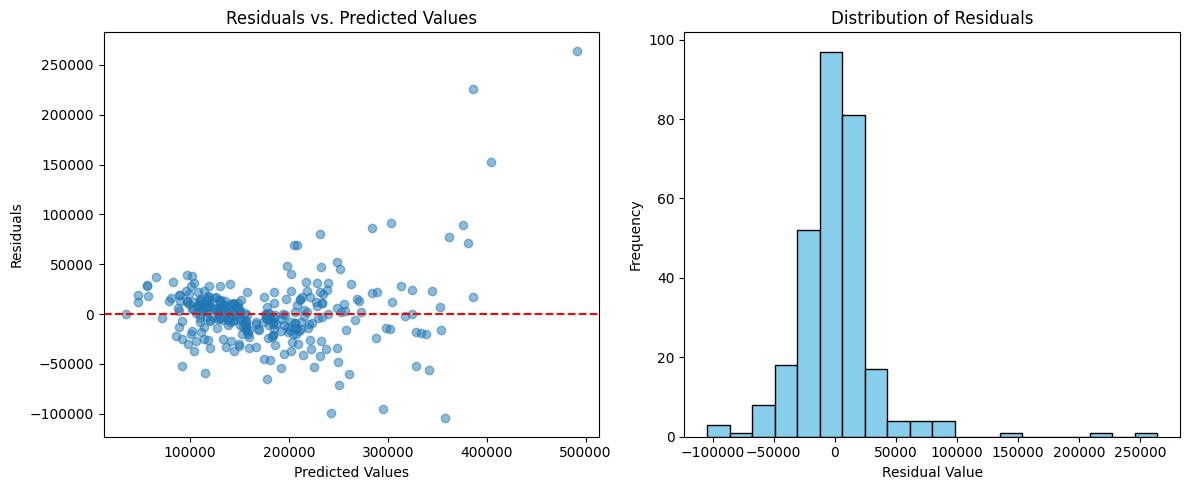

In [20]:
#Task11
residuals = y_test - y_pred

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=20, color="skyblue", edgecolor="black")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.tight_layout()
plt.show()

**Observation on Residual Pattern:**

The residuals are mostly centered around zero, but they are not completely randomly scattered. For higher predicted house values, the residuals spread out further (a fan pattern), showing that the model makes larger errors on expensive houses.

In [21]:
#Task12
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display metrics
metrics_df = pd.DataFrame(
    {
        "Metric": [
            "Mean Absolute Error (MAE)",
            "Mean Squared Error (MSE)",
            "Root Mean Squared Error (RMSE)",
            "R-squared (R²)",
        ],
        "Value": [
            "$" + str(round(mae, 2)),
            "$" + str(round(mse, 2)),
            "$" + str(round(rmse, 2)),
            str(round(r2, 4)),
        ],
    }
)

print(metrics_df.to_string(index=False))

                        Metric          Value
     Mean Absolute Error (MAE)      $20998.55
      Mean Squared Error (MSE) $1200948854.74
Root Mean Squared Error (RMSE)      $34654.71
                R-squared (R²)         0.8434


**Task13**

MAE (Mean Absolute Error): The average dollar amount the predictions are off by.

MSE (Mean Squared Error): The average of squared errors, which penalizes large errors heavily.

RMSE (Root Mean Squared Error): The square root of MSE, giving an error value in actual dollars that heavily penalizes big mispredictions.

R² (R-squared): The percentage of variation in house prices explained by the model (ranges from 0 to 1).

**Which metric to show to a non-technical stakeholder?**

I would show MAE (Mean Absolute Error). It is the easiest to explain in plain English—for example: "On average, our model's price prediction is off by around $X."

In [22]:
#Task14
train_pred = model.predict(X_train)


train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

test_mae = mean_absolute_error(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)


comparison_df = pd.DataFrame(
    {
        "Metric": ["MAE", "MSE", "RMSE", "R²"],
        "Training Set": [
            "$" + str(round(train_mae, 2)),
            "$" + str(round(train_mse, 2)),
            "$" + str(round(train_rmse, 2)),
            str(round(train_r2, 4)),
        ],
        "Testing Set": [
            "$" + str(round(test_mae, 2)),
            "$" + str(round(test_mse, 2)),
            "$" + str(round(test_rmse, 2)),
            str(round(test_r2, 4)),
        ],
    }
)

print(comparison_df.to_string(index=False))

Metric  Training Set    Testing Set
   MAE     $20327.77      $20998.55
   MSE $1068938665.7 $1200948854.74
  RMSE     $32694.63      $34654.71
    R²        0.8208         0.8434


**Task15**

Meaning of a Large Gap: A large gap (where training performance is much better than testing performance) indicates overfitting, meaning the model memorized the training data rather than learning general patterns.Actual Result Analysis: The small difference between the training and testing metrics (especially $R^2$) shows that the Linear Regression model generalizes well to unseen data and does not suffer from significant overfitting.

**Task16**
**Most Influential Features:**

OverallQual: It directly scales from 1 to 10, so each step increase adds a massive amount to the house price.

GrLivArea: Even though its coefficient per square foot might look smaller than quality ratings, houses have thousands of square feet, leading to a huge total impact on price.

Neighborhood: Certain location categories heavily drive price upwards or downwards.

**Caution on Scale Differences:**

A larger coefficient does not always mean a feature is more important. For instance, OverallQual changes in tiny steps (1 to 10), so its coefficient per 1-unit increase is large. In contrast, GrLivArea is measured in thousands of units (square feet), so its per-unit coefficient appears smaller, yet the total dollar impact is equally or more significant.

**Task17**

Our Linear Regression model predicts house prices reasonably well, capturing most of the variance in sales prices without overfitting. Among all evaluation metrics, MAE (Mean Absolute Error) is the most useful because it expresses prediction error in real dollars, making it clear and intuitive to non-technical stakeholders. Overall quality (OverallQual) and living area (GrLivArea) have the strongest overall impact on driving house prices up. However, because the model's errors increase for high-end properties, adding non-linear terms or feature scaling could further improve future predictions.

In [26]:
#Task18

test_df = pd.read_csv('test.csv')

feature_cols = [col for col in short_dataset if col != 'SalePrice']
X_test_kaggle = test_df[feature_cols].copy()

In [27]:
numeric_cols = X_test_kaggle.select_dtypes(include=['number']).columns
categorical_cols = X_test_kaggle.select_dtypes(include=['object']).columns

In [28]:
X_test_kaggle[numeric_cols] = X_test_kaggle[numeric_cols].fillna(X_test_kaggle[numeric_cols].median())
for col in categorical_cols:
    X_test_kaggle[col] = X_test_kaggle[col].fillna(X_test_kaggle[col].mode()[0])

In [29]:
X_test_encoded = pd.get_dummies(X_test_kaggle, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train.columns, fill_value=0)

In [30]:
test_predictions = model.predict(X_test_encoded)

In [31]:
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': test_predictions
})

In [32]:
submission.to_csv('submission.csv', index=False)
print("Submission created successfully with shape:", submission.shape)

Submission created successfully with shape: (1459, 2)


In [33]:
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Task 19 — Kaggle Leaderboard Submission & Reflection

* **Public Leaderboard Score (Log RMSE):** 0.16783
* **Submission Status:** Successfully Evaluated
* **Approximate Prediction Error:** ~16.78% (Accuracy ~83.22%)

**Reflection:**
Submitting to Kaggle completed the full end-to-end machine learning workflow by evaluating my model on real-world unseen data. Achieving a log RMSE score of 0.16783 with a simple Linear Regression model demonstrated strong predictive performance using basic numerical and categorical features. Seeing my model benchmarked on a live global leaderboard highlighted both the effectiveness of linear models and the potential for further accuracy improvements through advanced feature engineering and regularized regression techniques.

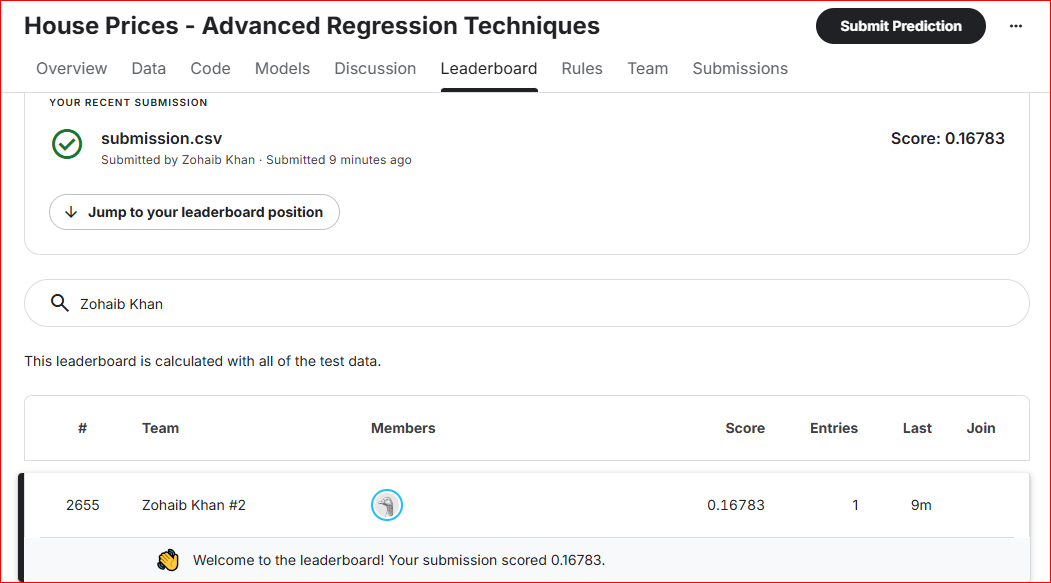